# 02 — Exploratory Data Analysis

**Phase 1: Data Understanding & EDA** · Owner: Ahamed M.A.U (IT24101779) · Group AI-39

Continues from `01_data_understanding.ipynb`. This notebook covers the guide's §5.1 steps 4–6:

- **Part A: target and data quality.** Outcome distribution, missing values, duplicates, validity checks.
- **Part B: patterns.** Home vs away goals, home advantage, team form, draws.

Every non-trivial finding is tagged with **why it matters for modelling** and is copied into `logs/eda_insight_log.md`.

## 1. Setup

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score

from src.db import load_matches

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

FIG_DIR = "../outputs/figures"
TABLE_DIR = "../outputs/tables"

# One fixed colour per outcome, used in every chart (colour-blind safe; checked with a palette validator)
OUTCOMES = ["Home Win", "Draw", "Away Win"]
OUTCOME_COLORS = {"Home Win": "#2a78d6", "Draw": "#eb6834", "Away Win": "#1baf7a"}

matches = load_matches().sort_values("date").reset_index(drop=True)
matches.shape

(25979, 119)

# Part A — Target and data quality

## 2. Target variable

The target follows decision D-004: compare full-time goals.

In [2]:
matches["target"] = np.select(
    [matches["home_team_goal"] > matches["away_team_goal"],
     matches["home_team_goal"] == matches["away_team_goal"],
     matches["home_team_goal"] < matches["away_team_goal"]],
    OUTCOMES,
    default="Unknown",   # numpy 2.x needs a string default when the choices are strings
)
assert (matches["target"] != "Unknown").all()

target_dist = pd.DataFrame({
    "matches": matches["target"].value_counts().reindex(OUTCOMES),
    "percent": (matches["target"].value_counts(normalize=True).reindex(OUTCOMES) * 100).round(2),
})
target_dist.loc["Total"] = [target_dist["matches"].sum(), target_dist["percent"].sum().round(2)]
target_dist["matches"] = target_dist["matches"].astype(int)
target_dist

,matches,percent
target,,
Home Win,11917,45.87
Draw,6596,25.39
Away Win,7466,28.74
Total,25979,100.00


In [3]:
# Check against the numbers stated in the Initial Submission
initial_submission = {"Home Win": 11917, "Draw": 6596, "Away Win": 7466}
for outcome, expected in initial_submission.items():
    actual = target_dist.loc[outcome, "matches"]
    assert actual == expected, f"{outcome}: expected {expected}, got {actual}"
print("Initial Submission class counts reproduced exactly from the raw data.")

Initial Submission class counts reproduced exactly from the raw data.


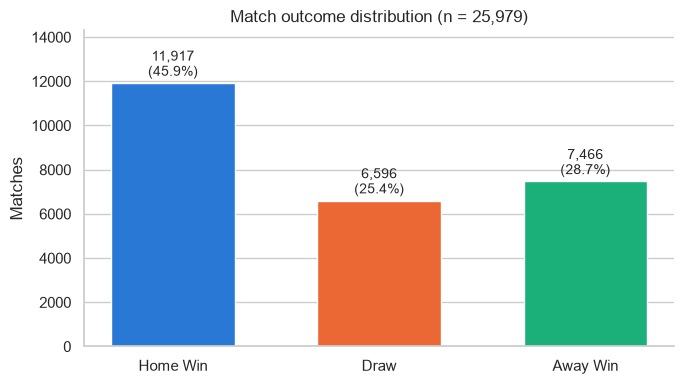

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = target_dist.loc[OUTCOMES, "matches"]
bars = ax.bar(OUTCOMES, counts, color=[OUTCOME_COLORS[o] for o in OUTCOMES], width=0.6)
for bar, (n, pct) in zip(bars, target_dist.loc[OUTCOMES].itertuples(index=False)):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 150, f"{n:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel("Matches")
ax.set_title("Match outcome distribution (n = 25,979)")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_02_target_distribution.png", dpi=150)
plt.show()

**Finding:** the classes are **imbalanced, but not extremely**. Home Win is the most common outcome (45.9%), and **Draw is
the minority class (25.4%)**. A model that always predicts "Home Win" is already right 46% of the time, so accuracy alone
would hide a model that never predicts draws. This supports **macro F1 as the primary metric** (D-008) and
`class_weight="balanced"` as an option for the models.

### 2.1 Majority-class baseline (the floor every model must beat)

In [5]:
y_true = matches["target"]
y_majority = pd.Series("Home Win", index=y_true.index)

baseline = pd.Series({
    "accuracy": accuracy_score(y_true, y_majority),
    "macro_f1": f1_score(y_true, y_majority, average="macro", labels=OUTCOMES, zero_division=0),
}).round(4)
baseline

accuracy    0.4587
macro_f1    0.2096
dtype: float64

Always predicting "Home Win" scores **45.9% accuracy but only 0.21 macro F1**, because it gets 0 recall on Draw and
Away Win. That gap is exactly why D-008 chose macro F1. Yusuf will recompute the baseline on the chronological
**test** set only; this full-data figure is a reference point.

### 2.2 Is the target stable across leagues and seasons?

In [6]:
by_league = pd.crosstab(matches["league_name"], matches["target"], normalize="index")[OUTCOMES]
by_season = pd.crosstab(matches["season"], matches["target"], normalize="index")[OUTCOMES]
(by_league * 100).round(1).sort_values("Home Win", ascending=False)

target,Home Win,Draw,Away Win
league_name,,,
Spain LIGA BBVA,48.8,23.2,28.0
Netherlands Eredivisie,47.8,23.7,28.4
Belgium Jupiler League,46.9,24.6,28.5
Italy Serie A,46.6,26.4,27.0
England Premier League,45.7,25.8,28.5
Switzerland Super League,45.7,24.3,30.0
Poland Ekstraklasa,45.3,27.3,27.3
Germany 1. Bundesliga,45.2,24.4,30.4
France Ligue 1,44.7,28.3,27.0


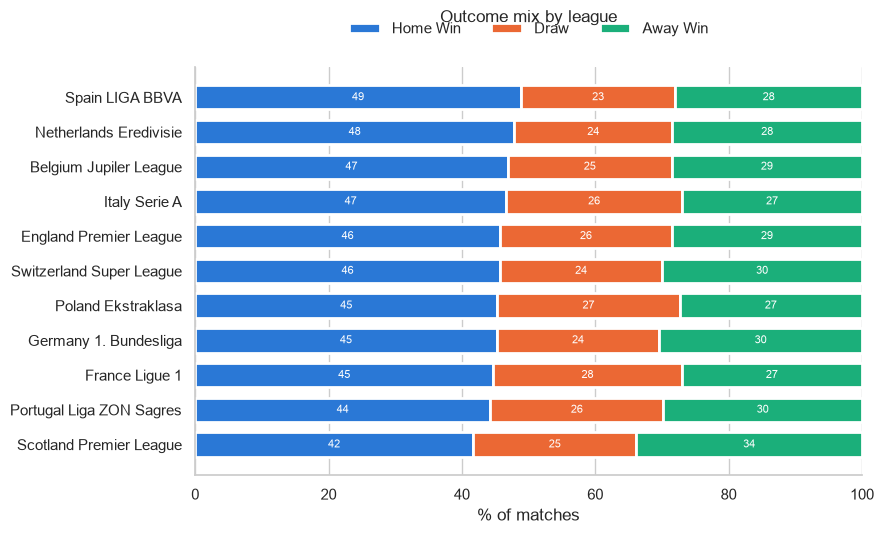

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
order = by_league.sort_values("Home Win").index
left = np.zeros(len(order))
for outcome in OUTCOMES:
    vals = by_league.loc[order, outcome].values * 100
    ax.barh(order, vals, left=left, color=OUTCOME_COLORS[outcome], label=outcome,
            edgecolor="white", linewidth=2, height=0.7)
    for y, (l, v) in enumerate(zip(left, vals)):
        ax.text(l + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white")
    left += vals
ax.set_xlim(0, 100)
ax.set_xlabel("% of matches")
ax.set_title("Outcome mix by league", pad=32)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.04), frameon=False)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_03_target_by_league.png", dpi=150)
plt.show()

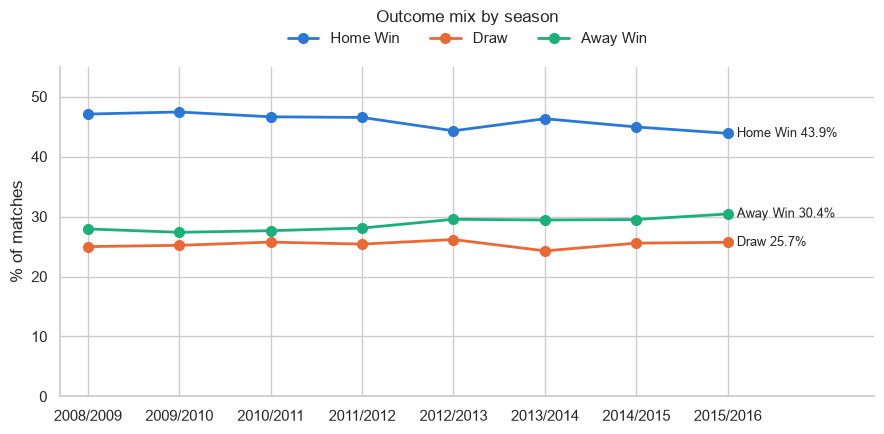

target,Home Win,Draw,Away Win
season,,,
2008/2009,47.1,25.0,27.9
2009/2010,47.4,25.2,27.4
2010/2011,46.6,25.7,27.6
2011/2012,46.5,25.4,28.1
2012/2013,44.3,26.2,29.5
2013/2014,46.3,24.3,29.4
2014/2015,44.9,25.6,29.5
2015/2016,43.9,25.7,30.4


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for outcome in OUTCOMES:
    s = by_season[outcome] * 100
    ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2, color=OUTCOME_COLORS[outcome], label=outcome)
    ax.text(len(s) - 1 + 0.1, s.iloc[-1], f"{outcome} {s.iloc[-1]:.1f}%", va="center", fontsize=9)
ax.set_ylim(0, 55)
ax.set_xlim(-0.3, len(by_season) + 0.6)
ax.set_ylabel("% of matches")
ax.set_title("Outcome mix by season", pad=32)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_04_target_by_season.png", dpi=150)
plt.show()
(by_season * 100).round(1)

**Findings:**

- **Across leagues** the home-win rate ranges from **41.7% (Scotland)** to **48.8% (Spain)**. The draw rate ranges from
  **23.2% (Spain)** to **28.3% (France)**. The leagues differ, but not dramatically, so one model across all leagues is
  reasonable. League could still be a useful context feature.
- **Across seasons** the home-win rate **drifts down** from 47.1% (2008/09) to 43.9% (2015/16), while away wins rise from
  27.9% to 30.4%. Draws stay flat at about 25%.
- **Why it matters:** with a chronological split (D-009), the **test seasons have fewer home wins than training**.
  A model that over-relies on "home team wins" will be slightly worse on the test set than in training. The
  majority-baseline accuracy on the test set will also be below the 45.9% seen on the full data. Yusuf should report the
  class distribution of train vs test (guide §5.5 step 3).

## 3. Missing values

`01_data_understanding.ipynb` showed the average missingness per column group. Here we check **where** the gaps are,
because values missing at random and values missing for whole leagues have to be handled differently.

In [9]:
raw_cols = list(load_matches(with_names=False).columns)          # the 115 original columns
missing = matches[raw_cols].isna().mean().mul(100).round(1)
print(f"{(missing > 0).sum()} of {len(raw_cols)} raw columns have missing values.")
print("Complete columns:", ", ".join(missing[missing == 0].index))

# Columns with the same % missing belong to the same source, so group them
(missing[missing > 0].groupby(missing).apply(lambda s: f"{len(s)} cols, e.g. {', '.join(s.index[:3])}")
 .sort_index(ascending=False).to_frame("columns"))

104 of 115 raw columns have missing values.
Complete columns: id, country_id, league_id, season, stage, date, match_api_id, home_team_api_id, away_team_api_id, home_team_goal, away_team_goal


,columns
57.0,"3 cols, e.g. PSH, PSD, PSA"
45.5,"6 cols, e.g. GBH, GBD, GBA"
45.3,"8 cols, e.g. goal, shoton, shotoff"
34.2,"3 cols, e.g. SJH, SJD, SJA"
13.3,"3 cols, e.g. IWH, IWD, IWA"
13.2,"3 cols, e.g. LBH, LBD, LBA"
13.1,"9 cols, e.g. BWH, BWD, BWA"
13.0,"3 cols, e.g. B365H, B365D, B365A"
7.1,"40 cols, e.g. home_player_X3, home_player_X4, ..."
7.0,"4 cols, e.g. home_player_X1, home_player_X2, h..."


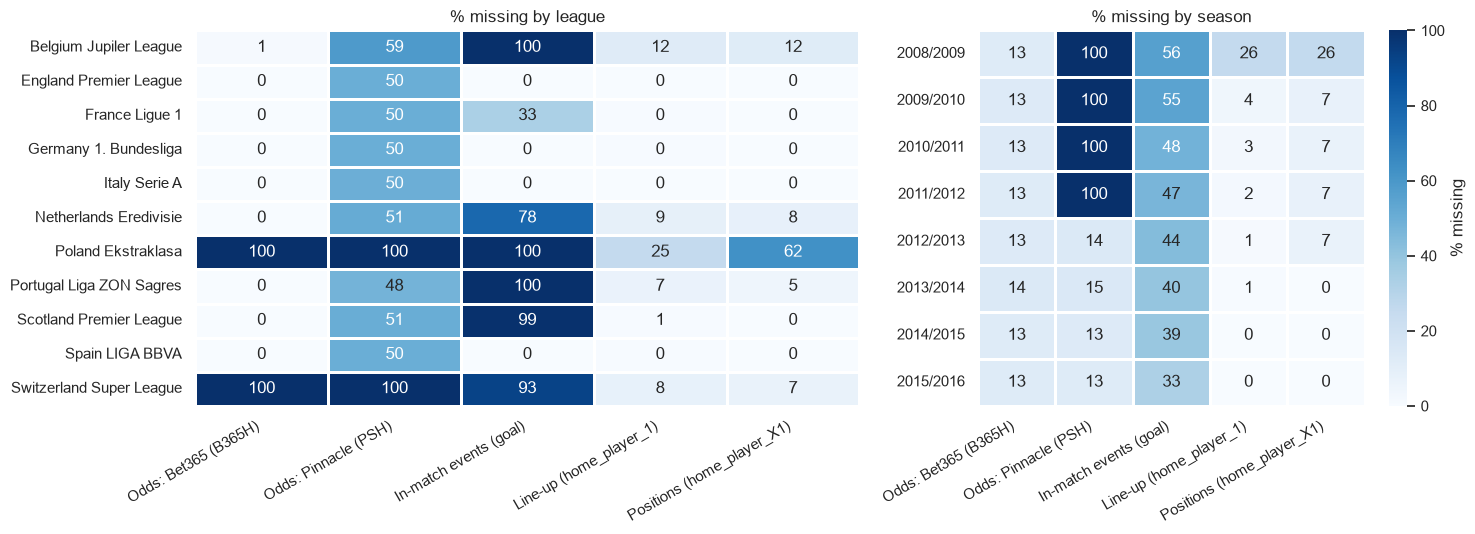

In [10]:
# One representative column per group, so the pattern is readable
group_cols = {
    "Odds: Bet365 (B365H)": "B365H",
    "Odds: Pinnacle (PSH)": "PSH",
    "In-match events (goal)": "goal",
    "Line-up (home_player_1)": "home_player_1",
    "Positions (home_player_X1)": "home_player_X1",
}
miss_league = matches.groupby("league_name")[list(group_cols.values())].apply(lambda d: d.isna().mean() * 100)
miss_season = matches.groupby("season")[list(group_cols.values())].apply(lambda d: d.isna().mean() * 100)
miss_league.columns = miss_season.columns = list(group_cols.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [11, 8]})
for ax, data, title in [(axes[0], miss_league, "by league"), (axes[1], miss_season, "by season")]:
    sns.heatmap(data, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=ax is axes[1],
                cbar_kws={"label": "% missing"}, linewidths=1, linecolor="white", ax=ax)
    ax.set_title(f"% missing {title}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/eda_05_missing_by_league_season.png", dpi=150)
plt.show()

In [11]:
miss_league.round(1)

,Odds: Bet365 (B365H),Odds: Pinnacle (PSH),In-match events (goal),Line-up (home_player_1),Positions (home_player_X1)
league_name,,,,,
Belgium Jupiler League,1.3,58.9,100.0,12.4,12.0
England Premier League,0.0,50.0,0.0,0.0,0.0
France Ligue 1,0.1,50.0,33.4,0.4,0.0
Germany 1. Bundesliga,0.0,50.0,0.0,0.5,0.0
Italy Serie A,0.2,49.8,0.1,0.0,0.0
Netherlands Eredivisie,0.1,51.2,78.3,8.7,8.4
Poland Ekstraklasa,100.0,100.0,99.6,25.4,62.5
Portugal Liga ZON Sagres,0.4,47.7,100.0,6.9,5.1
Scotland Premier League,0.0,50.8,99.3,0.7,0.0


In [12]:
miss_season.round(1)

,Odds: Bet365 (B365H),Odds: Pinnacle (PSH),In-match events (goal),Line-up (home_player_1),Positions (home_player_X1)
season,,,,,
2008/2009,12.9,100.0,56.4,25.6,25.9
2009/2010,13.1,100.0,55.0,4.2,7.4
2010/2011,13.0,100.0,48.3,3.0,7.4
2011/2012,12.6,100.0,46.8,2.1,7.5
2012/2013,13.1,14.4,44.0,1.2,7.4
2013/2014,14.3,14.6,39.8,0.6,0.0
2014/2015,12.7,13.1,38.9,0.1,0.0
2015/2016,12.7,12.9,32.9,0.2,0.0


**Findings:** the missingness is **structural, not random**. It depends on the league and the season:

| Column group | Pattern | Why it matters / action |
|---|---|---|
| **Goals, teams, date, season, stage** | **0% missing** | Target and every history feature can be computed for all 25,979 matches. No imputation needed for the core pipeline. |
| **Odds (Bet365 etc.)** | ~13% overall, but **100% missing for Poland and Switzerland**, ~0% elsewhere | Excluded as features (D-011). Mean imputation would invent odds for two entire leagues. |
| **Odds (Pinnacle)** | 100% missing before 2012/13 | Same: not usable. |
| **In-match events** | **Only complete for England, Germany, Italy and Spain**; 100% missing for Belgium and Portugal | Leakage anyway (D-010). Even if not, using them would silently restrict the model to 4 leagues. |
| **Line-ups / positions** | 26% missing in 2008/09, < 8% after; worst in Poland (25% line-ups, 62% positions) | Out of scope (team-level lens). |

**Key consequence for Umair:** after dropping the excluded groups, the modelling table has **no missing raw values**.
Missing values will only appear in **engineered** features, for example a team's first matches with no "last 5" history
yet (cold start), and in Team_Attributes before 2010-02-22. Those need their own handling, analysed in Part B.

## 4. Duplicates

In [13]:
key = ["date", "home_team_api_id", "away_team_api_id"]
team_day = pd.concat([
    matches[["date", "home_team_api_id"]].rename(columns={"home_team_api_id": "team"}),
    matches[["date", "away_team_api_id"]].rename(columns={"away_team_api_id": "team"}),
])
dup_checks = pd.Series({
    "Fully identical rows (excluding id)": matches.drop(columns=["id"]).duplicated().sum(),
    "Duplicate match_api_id": matches["match_api_id"].duplicated().sum(),
    "Same date + home + away team": matches.duplicated(key).sum(),
    "Team playing twice on the same day": team_day.duplicated().sum(),
    "Same season + home + away team (repeat fixture)": matches.duplicated(["season", "home_team_api_id", "away_team_api_id"]).sum(),
})
dup_checks.to_frame("count")

,count
Fully identical rows (excluding id),0
Duplicate match_api_id,0
Same date + home + away team,0
Team playing twice on the same day,0
Same season + home + away team (repeat fixture),1470


In [14]:
repeat = matches[matches.duplicated(["season", "home_team_api_id", "away_team_api_id"], keep=False)]
repeat["league_name"].value_counts().rename("rows involved in a repeated fixture")

league_name
Scotland Premier League     1502
Switzerland Super League    1404
Name: rows involved in a repeated fixture, dtype: int64

**Findings:**

- **No true duplicates.** No identical rows, no repeated `match_api_id`, and no fixture recorded twice on the same date.
- **No team plays twice on the same day.** The date has no kickoff time, but **ordering by date alone is enough** to know
  which of a team's matches came first. "Strictly earlier matches" (guide §5.3) is unambiguous.
- The repeat home fixtures within a season are **only in Scotland and Switzerland**, whose formats have teams meet 3–4
  times a season. These are real, separate matches, **not duplicates**. **Do not de-duplicate on (season, home, away).**

## 5. Validity checks

In [15]:
validity = pd.Series({
    "Null home/away goals": matches[["home_team_goal", "away_team_goal"]].isna().any(axis=1).sum(),
    "Negative goals": (matches[["home_team_goal", "away_team_goal"]] < 0).any(axis=1).sum(),
    "Team plays itself": (matches["home_team_api_id"] == matches["away_team_api_id"]).sum(),
    "Date outside its season (Jul–Jun)": (~matches.apply(
        lambda r: pd.Timestamp(f"{r['season'][:4]}-07-01") <= r["date"] < pd.Timestamp(f"{r['season'][5:]}-07-01"),
        axis=1)).sum(),
    "Missing team name after join": matches[["home_team_name", "away_team_name"]].isna().any(axis=1).sum(),
})
validity.to_frame("count")

,count
Null home/away goals,0
Negative goals,0
Team plays itself,0
Date outside its season (Jul–Jun),0
Missing team name after join,0


In [16]:
matches["total_goals"] = matches["home_team_goal"] + matches["away_team_goal"]
print("Goals per side: home 0–%d, away 0–%d" % (matches["home_team_goal"].max(), matches["away_team_goal"].max()))
print("Matches with 10+ total goals:", (matches["total_goals"] >= 10).sum())
matches.loc[matches["total_goals"] >= 10,
            ["date", "league_name", "home_team_name", "away_team_name", "home_team_goal", "away_team_goal"]]

Goals per side: home 0–10, away 0–9
Matches with 10+ total goals: 14


,date,league_name,home_team_name,away_team_name,home_team_goal,away_team_goal
4426,2009-11-08,France Ligue 1,Olympique Lyonnais,Olympique de Marseille,5,5
4499,2009-11-22,England Premier League,Tottenham Hotspur,Wigan Athletic,9,1
6424,2010-05-05,Scotland Premier League,Motherwell,Hibernian,6,6
7392,2010-10-24,Netherlands Eredivisie,PSV,Feyenoord,10,0
10110,2011-08-28,England Premier League,Manchester United,Arsenal,8,2
10908,2011-11-06,Netherlands Eredivisie,FC Utrecht,Ajax,6,4
14689,2012-12-29,England Premier League,Arsenal,Newcastle United,7,3
15567,2013-03-30,Germany 1. Bundesliga,FC Bayern Munich,Hamburger SV,9,2
16187,2013-05-19,England Premier League,West Bromwich Albion,Manchester United,5,5
17175,2013-10-30,Spain LIGA BBVA,Real Madrid CF,Sevilla FC,7,3


**Findings:**

- All checks return **0**. There are no null or negative goals, no team plays itself, every date falls inside its season,
  and every team ID resolves to a name.
- The most extreme scores (e.g. **PSV 10–0 Feyenoord**, 2010; **Real Madrid 10–2 Rayo Vallecano**, 2015;
  **Deportivo 2–8 Real Madrid**, 2014) are **real, well-known results**, not entry errors. They are **kept**: removing
  genuine thrashings would distort the rolling goal averages of the teams involved. Their effect on a 5-match average is
  temporary, and scaling (or tree models) handles the range.

## 6. Data-quality summary (Part A)

| # | Finding | Why it matters for modelling | Action / owner |
|---|---|---|---|
| A1 | Class split reproduces the Initial Submission exactly (45.87 / 25.39 / 28.74) | Confirms target logic and dataset version | None |
| A2 | Draw is the minority (25.4%); majority baseline = 45.9% accuracy but 0.21 macro F1 | Accuracy misleads; use macro F1 (D-008), consider `class_weight="balanced"` | Yusuf |
| A3 | Home-win rate falls from 47.1% (2008/09) to 43.9% (2015/16) | The chronological test set has fewer home wins than training; report train/test class balance | Yusuf |
| A4 | Home-win rate varies by league (41.7% Scotland – 48.8% Spain) | League is a candidate context feature | Umair |
| A5 | Core columns (goals, teams, date) are 100% complete | No imputation needed for raw inputs | Umair |
| A6 | Odds missing for whole leagues (Poland, Switzerland), events only complete for 4 leagues | Structural missingness; imputing would fabricate data. Confirms exclusion (D-010, D-011) | Umair |
| A7 | No duplicates; no team plays twice on one day | Date ordering is enough for strictly-earlier history features | Umair |
| A8 | Repeated (season, home, away) fixtures in Scotland/Switzerland are real | Do not de-duplicate on that key | Umair |
| A9 | Extreme scores (up to 10–0) are genuine | Keep them; no outlier removal on goals | Umair |